[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Sample Tokens: ['indian', 'institute', 'technology', 'jodhpur', 'offers', 'undergraduate', 'and', 'postgraduate', 'programs', 'engineering', 'and', 'sciences', 'the', 'institute', 'focuses', 'research', 'innovation', 'and', 'academic', 'excellence']
Corpus saved!

Dataset Stats:
Documents: 3
Total Tokens: 109
Vocabulary Size: 73


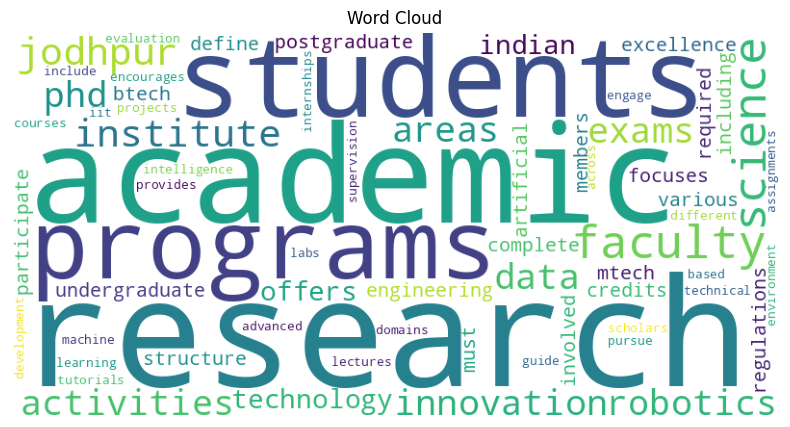


Models trained!

CBOW Results:

research → [('engage', 0.18899263441562653), ('domains', 0.1884230673313141), ('are', 0.18448899686336517), ('innovation', 0.16077595949172974), ('machine', 0.16012069582939148)]

students → [('postgraduate', 0.3693598210811615), ('evaluation', 0.21298164129257202), ('members', 0.202286958694458), ('science', 0.20050278306007385), ('exams', 0.17329862713813782)]

phd → [('pursue', 0.24876618385314941), ('environment', 0.23927181959152222), ('guide', 0.15077760815620422), ('faculty', 0.15061640739440918), ('sciences', 0.12898477911949158)]

exams → [('postgraduate', 0.3149270713329315), ('are', 0.31357765197753906), ('indian', 0.18318556249141693), ('encourages', 0.18207812309265137), ('students', 0.173298642039299)]

Skip-gram Results:

research → [('engage', 0.18979407846927643), ('domains', 0.18781039118766785), ('are', 0.18588922917842865), ('machine', 0.16257323324680328), ('innovation', 0.1613653600215912)]

students → [('postgraduate', 0.370560228

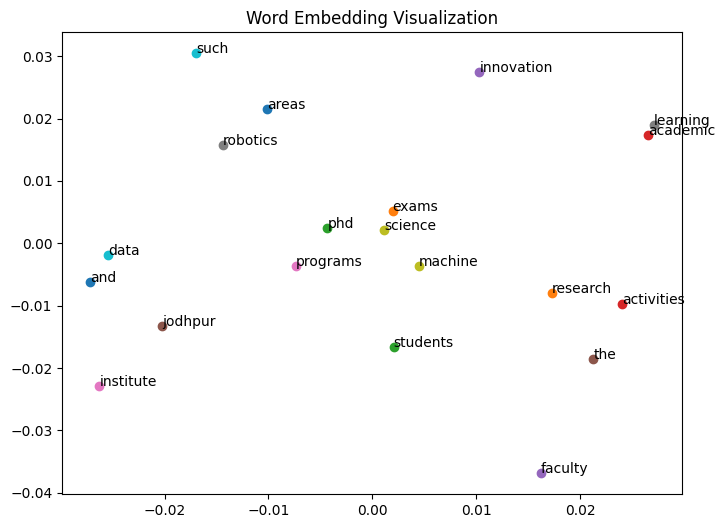


From-scratch Word2Vec completed


In [5]:
# ================================
# INSTALL LIBRARIES (RUN ONCE)
# ================================
!pip install nltk gensim wordcloud scikit-learn

# ================================
# IMPORTS
# ================================
import re
import nltk
import numpy as np
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ================================
# DOWNLOAD TOKENIZERS (FIX ERROR)
# ================================
nltk.download('punkt')
nltk.download('punkt_tab')   # 🔥 IMPORTANT FIX

# ================================
# RAW DATA
# ================================
text = """
Indian Institute of Technology Jodhpur offers undergraduate and postgraduate programs in engineering and sciences.
The institute focuses on research, innovation, and academic excellence. Students participate in various academic activities.

The academic regulations define the structure of BTech, MTech, and PhD programs. Students must complete required credits and exams.

Faculty members are involved in research areas including artificial intelligence, data science, and robotics.

Courses include lectures, tutorials, and labs. Evaluation is based on assignments and exams.

Research scholars pursue PhD programs under faculty supervision.

IIT Jodhpur provides an academic environment that encourages research, innovation, and technical development.

Students engage in projects, internships, and research activities across different domains.

Faculty guide students in advanced areas such as machine learning, robotics, and data science.
"""

# ================================
# PREPROCESSING
# ================================

# Lowercase
text = text.lower()

# Remove punctuation & numbers
text = re.sub(r'[^a-z\s]', '', text)

# Tokenization (safe fallback)
try:
    tokens = word_tokenize(text)
except:
    tokens = text.split()

# Remove short words
tokens = [w for w in tokens if len(w) > 2]

print("Sample Tokens:", tokens[:20])

# ================================
# SAVE CORPUS
# ================================
with open("corpus.txt", "w") as f:
    f.write(" ".join(tokens))

print("Corpus saved!")

# ================================
# DATASET STATS
# ================================
num_docs = 3
total_tokens = len(tokens)
vocab_size = len(set(tokens))

print("\nDataset Stats:")
print("Documents:", num_docs)
print("Total Tokens:", total_tokens)
print("Vocabulary Size:", vocab_size)

# ================================
# WORD CLOUD
# ================================
wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(tokens))

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.savefig("wordcloud.png")
plt.show()

# ================================
# PREPARE SENTENCES
# ================================
sentences = [tokens[i:i+10] for i in range(0, len(tokens), 10)]

# ================================
# TRAIN MODELS
# ================================
# CBOW small
cbow_small = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=0)

# CBOW large
cbow_large = Word2Vec(sentences, vector_size=100, window=5, min_count=1, sg=0)

# Skip-gram
skip_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, sg=1)

print("\nModels trained!")

# ================================
# NEAREST NEIGHBORS
# ================================
words = ["research", "students", "phd", "exams"]

print("\nCBOW Results:")
for w in words:
    if w in cbow_large.wv:
        print(f"\n{w} →", cbow_large.wv.most_similar(w, topn=5))

print("\nSkip-gram Results:")
for w in words:
    if w in skip_model.wv:
        print(f"\n{w} →", skip_model.wv.most_similar(w, topn=5))

# ================================
# ANALOGY TASK
# ================================
print("\nAnalogy (UG : BTech :: PG : ?)")
print(cbow_large.wv.most_similar(positive=["btech", "phd"], negative=["students"]))

# ================================
# PCA VISUALIZATION
# ================================
words_vis = list(cbow_large.wv.index_to_key)[:20]
vectors = [cbow_large.wv[w] for w in words_vis]

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
for i, word in enumerate(words_vis):
    plt.scatter(coords[i,0], coords[i,1])
    plt.text(coords[i,0], coords[i,1], word)

plt.title("Word Embedding Visualization")
plt.savefig("pca.png")
plt.show()

# ================================
# FROM-SCRATCH CBOW
# ================================
vocab = list(set(tokens))
word_to_idx = {w:i for i,w in enumerate(vocab)}
V = len(vocab)
N = 10

W1 = np.random.rand(V, N)
W2 = np.random.rand(N, V)

lr = 0.01
window_size = 2

pairs = []
for i in range(window_size, len(tokens)-window_size):
    context = tokens[i-window_size:i] + tokens[i+1:i+window_size+1]
    target = tokens[i]
    pairs.append((context, target))

for context, target in pairs[:50]:
    x = np.zeros(V)
    for w in context:
        x[word_to_idx[w]] += 1

    h = np.dot(x, W1)
    u = np.dot(h, W2)

    y_pred = np.exp(u) / np.sum(np.exp(u))

    y_true = np.zeros(V)
    y_true[word_to_idx[target]] = 1

    error = y_pred - y_true

    W2 -= lr * np.outer(h, error)
    W1 -= lr * np.outer(x, np.dot(W2, error))

print("\nFrom-scratch Word2Vec completed")

In [6]:
from google.colab import files
files.download("corpus.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
model_300 = Word2Vec(sentences, vector_size=300, window=5, min_count=1, sg=0)
vec = model_300.wv["research"]
print("research -", ", ".join(map(str, vec)))

research - -0.0027437615, 0.0031030707, -6.447439e-05, -0.00065172237, 0.001540615, -0.0013771887, 0.00092267204, 0.002324945, 0.0020185313, -0.0025077108, 0.0031281966, 0.0015563538, 0.0013190876, -0.0020771734, 0.0028177577, -0.000714452, 0.002946804, -0.0017873175, -0.0027024657, 0.0022704308, 0.00055704627, -0.00073315477, 0.0031757734, 0.003160055, -0.00326055, 0.0008275949, 0.0020463103, 0.0012927044, 0.00066805223, 0.00013934041, 0.0002296844, -0.0012736099, -0.0023754167, -0.0006915163, 0.0013086349, 0.0029483123, 0.0030934613, -0.0019930967, -0.0031300066, 0.0032482408, 0.0011336996, 0.001716962, 0.002095322, -0.0009333341, 0.0024497877, 0.00095440523, 0.00095883914, -0.000795437, -0.0010395972, -0.0007835502, 0.0014307487, 2.6405836e-05, -0.0031943077, -0.0032197135, -0.0020403462, -3.3245422e-05, 0.00066638284, 0.0031418852, 0.0018677188, -0.0014302229, 8.556008e-05, 0.0016651313, 0.0025654563, -0.0003821559, 0.0014372257, -0.0019290156, -0.0002712991, 0.002707807, -0.000790